<a href="https://colab.research.google.com/github/voronv27/projects-in-ai-and-ml/blob/main/HW6/Homework6_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Part 2: Mini Research Task on a Novel AI Topic

##Task 2

###Topic Overview:

I chose to research diffusion models.

A diffusion model is a generative AI model that starts with random noise and "turns it into" a desired output such as an image. The problem that diffusion models try to solve is being able to generate something from scratch and have it be high-quality. Thus far, diffusion models have shown record-breaking performance in tasks such as image synthesis, outperforming GANs which were the best models for that task previously.

The main idea behind model training is that the diffusion model is trained on data with intensifying noise added to it (which is known as the diffusion process), and then it learns to remove that noise to generate new data samples. There are 3 main types of diffusion models being researched, which are all trained in this way: denoising diffusion probabalistic models (DDPMs), score-based generative models (SGMs), and stochastic differential equations (Score SDEs).

A DDPM makes use of a forward and reverse Markov chain to add noise to data and convert noise back to data, respectively.

SGMs have a score function (Stein score). The Stein score is a vector field that points to directions along which the probability density function has the largest growth rate. As with DDPMs, SGMs add intensifying noise to the data. From there, they train a NN model known as a noise-conditional score network (NCSN) on noise levels to estimate the score functions for noisy data. The model generates samples by chaining the score functions at decreasing noise levels.

Finally, Score SDEs are a generalization of DDPMs and SGMs where we have infinite time steps/noise levels. Both the perturbation (adding noise) and denoising processes are solutions to stochastic differential equations (SDEs). This type of model leverages SDEs for adding noise to the data, and estimates score functions for the denoising process.

###Hands-On Component:

For this small hands-on component, we will examine how the number of denoising steps affects a pretrained DDPM model (google/ddpm-celebahq-256).

In [1]:
from diffusers import DDPMPipeline

pipe = DDPMPipeline.from_pretrained("google/ddpm-celebahq-256")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/1 [00:00<?, ?it/s]

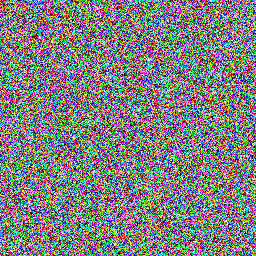

  0%|          | 0/5 [00:00<?, ?it/s]

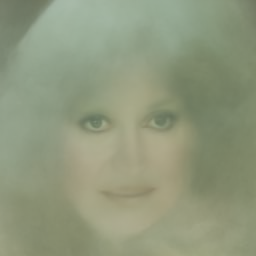

  0%|          | 0/10 [00:00<?, ?it/s]

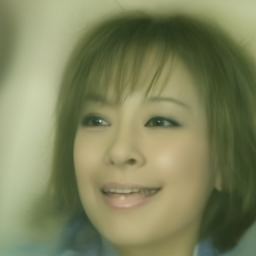

  0%|          | 0/20 [00:00<?, ?it/s]

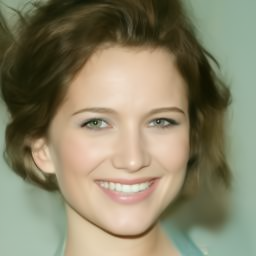

  0%|          | 0/50 [00:00<?, ?it/s]

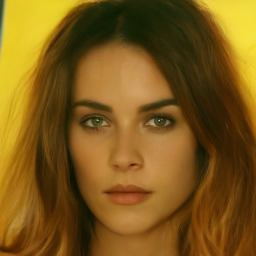

  0%|          | 0/100 [00:00<?, ?it/s]

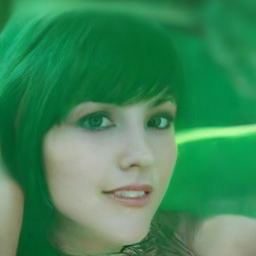

In [6]:
# try various denoising steps
images = []
for steps in [1, 5, 10, 20, 50, 100]:
  image = pipe(num_inference_steps=steps).images[0]
  images.append(image)
  display(image)

As we can see, with only one denoising step, all we can see is random noise. As the number of denoising steps increases, the image quality becomes better and more realistic--there is less blur around the edges, the background gets more detail, and the colors are more "realistic" and distinct. The tradeoff is that the more steps that are added, the longer the model takes to generate the image.

###Small Figure:

Here is a side-by-side figure of the above images, to better visualize the effect of denoising steps on image quality:

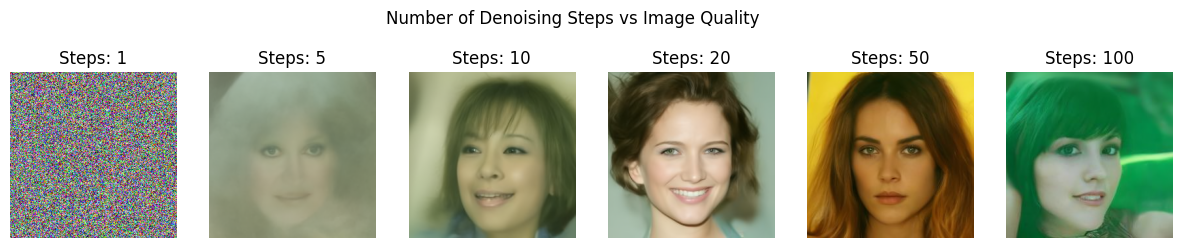

In [7]:
import matplotlib.pyplot as plt

steps = [1, 5, 10, 20, 50, 100]
fig, axs = plt.subplots(1, 6, figsize=(15, 3))

for i, steps in enumerate(steps):
  image = images[i]
  axs[i].imshow(image)
  axs[i].axis('off')
  axs[i].set_title(f'Steps: {steps}')

plt.suptitle("Number of Denoising Steps vs Image Quality")
plt.show()


###Limitations and Challenges:

As mentioned in Diffusion Models: A Comprehensive Survey of Methods and Applications, one challenge for diffusion models is that they don't work as well with special data structures. Diffusion models have performed extremely well for images and audio, but they are not meant for non-continous data domains (at least, not as-is). Both Gaussian noise perturbation (used by DDPMs) and the score functions used by SGMs and Score SDEs are defined on continous data domains. As such, for discrete data, the model must be adapted. For example, VQ-Diffusion replaces Gaussian noise with a random walk or random masking on the discrete data space.

Some more general limitations of diffusion models are slow sampling due to how many steps are needed to generate a high-quality sample in the denoising process and memory usage (due to storing multiple intermediate steps during training, the model consumes a lot of memory). In addition, the model can be difficult to implement well: it has high complexity in both architecture and training and needs to be fine-tuned carefully.


###Possible Follow-Up Experiment

In this research task, I examined the effect of the number of denoising steps on the image quality. Another important factor that affects image quality is the scheduler used (the noise schedule is used to add noise to the image). As such, a good follow-up experiment would be to experiment with and compare different schedulers and see how it affects the generated image quality.

If I were do to this experiment, I expect I would see that some schedulers converge faster (i.e. they take less steps to produce a good image), while others may take longer. Some schedulers may take more steps to produce a good image, but create higher-quality images with sharper edges.

###Sources:

Sources:

[Diffusion Models: A Comprehensive Survey of Methods and Applications](https://arxiv.org/pdf/2209.00796)

[Introduction to Diffusion Models for Machine Learning](https://www.superannotate.com/blog/diffusion-models)

[What are Diffusion Models?](https://www.geeksforgeeks.org/artificial-intelligence/what-are-diffusion-models/)

[google/ddpm-celebahq-256 Model Card](https://huggingface.co/google/ddpm-celebahq-256)